In [ ]:
# ASSIGNMENT 7 - HEART DATASET

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statistics
from scipy.stats import norm

In [ ]:
# 1. Load dataset
df = pd.read_csv("heart.csv")

In [ ]:
# 2. Display first 5 rows
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
# 3. Info and Describe
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [ ]:
print("\nStatistical Summary:\n")
print(df.describe())


Statistical Summary:

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


In [ ]:
# 4. Identify categorical & numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

print("\nCategorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))


Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


In [ ]:
# 5. Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Section B – Data Cleaning


# 1 & 2. Handle missing values
df = df.dropna()

In [ ]:
# 3. Confirm dataset is clean
print("\nAfter Cleaning (Missing Values):\n", df.isnull().sum())


After Cleaning (Missing Values):
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
# Section C – Statistical Analysis


# Selected columns 
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [ ]:
print("\n--- Statistical Analysis ---")

for col in cols:
    print(f"\nColumn: {col}")
    
    # Mean
    mean_val = df[col].mean()
    print("Mean:", mean_val)
    
    # Standard Deviation
    std_val = df[col].std()
    print("Standard Deviation:", std_val)
    
    # Skewness
    skew_val = df[col].skew()
    print("Skewness:", skew_val)


--- Statistical Analysis ---

Column: Age
Mean: 53.510893246187365
Standard Deviation: 9.43261650673201
Skewness: -0.19593302867569365

Column: RestingBP
Mean: 132.39651416122004
Standard Deviation: 18.5141541199078
Skewness: 0.1798393100516288

Column: Cholesterol
Mean: 198.7995642701525
Standard Deviation: 109.38414455220348
Skewness: -0.6100864307268192

Column: MaxHR
Mean: 136.80936819172112
Standard Deviation: 25.4603341382503
Skewness: -0.14435941846180994

Column: Oldpeak
Mean: 0.8873638344226579
Standard Deviation: 1.0665701510493257
Skewness: 1.0228720218107528


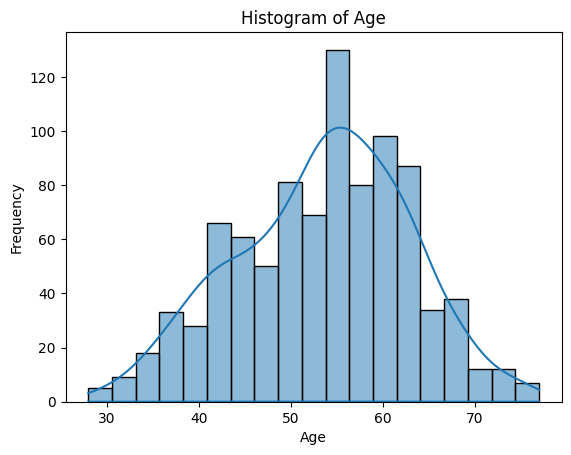

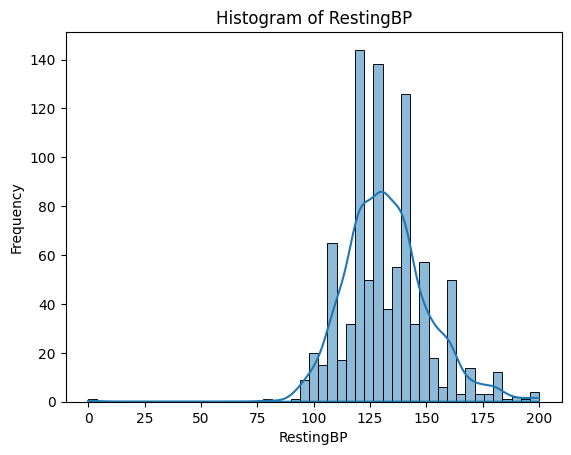

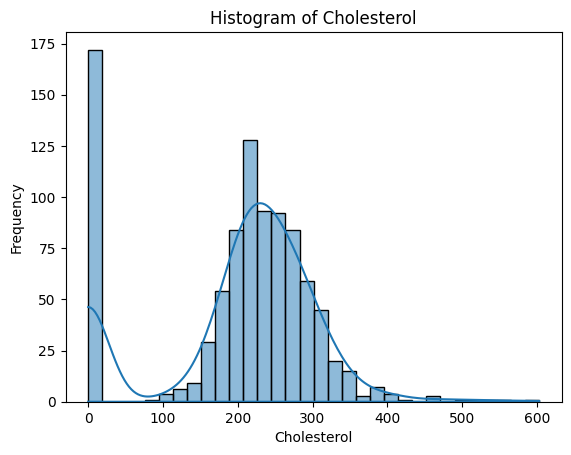

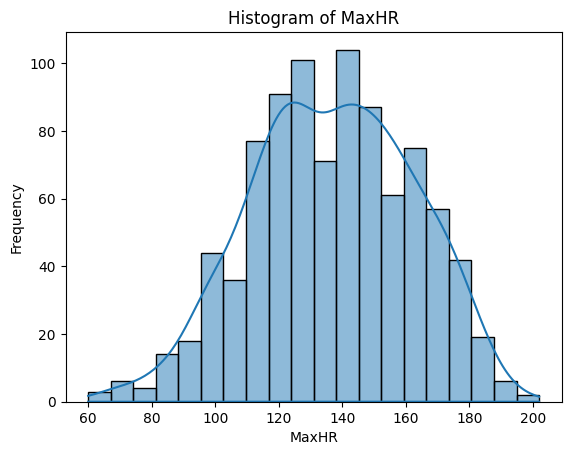

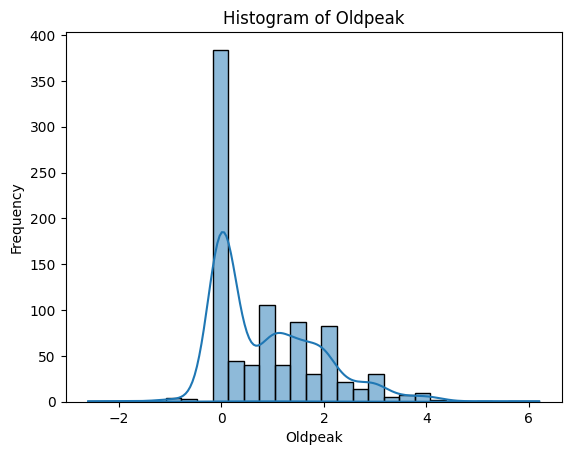

In [ ]:
# Section D – Histogram


for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    
    # Normal distribution curve
    mean = df[col].mean()
    std = df[col].std()
    x = np.linspace(df[col].min(), df[col].max(), 100)
    plt.plot(x, norm.pdf(x, mean, std))
    
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

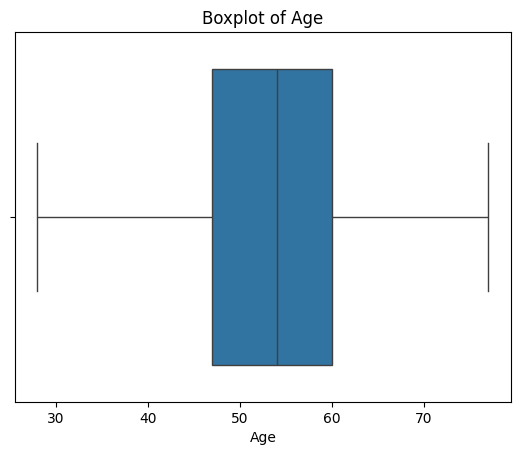

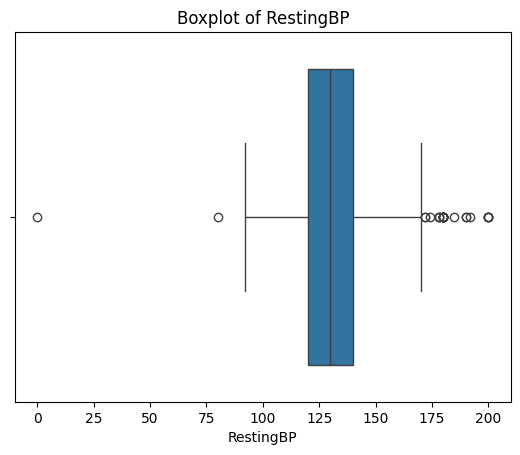

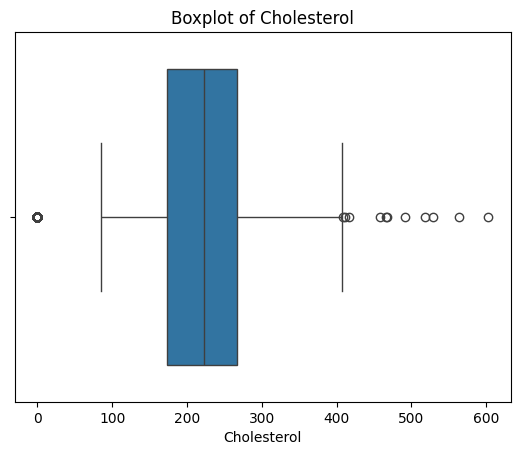

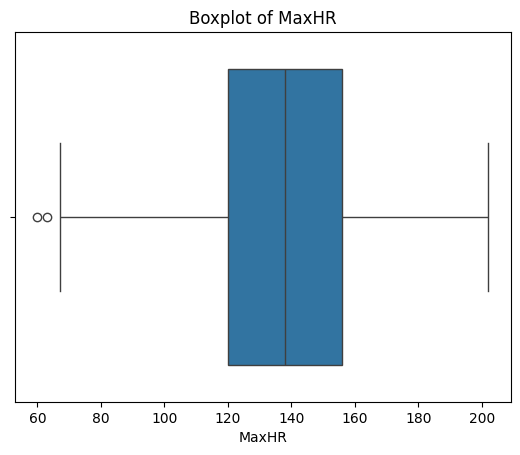

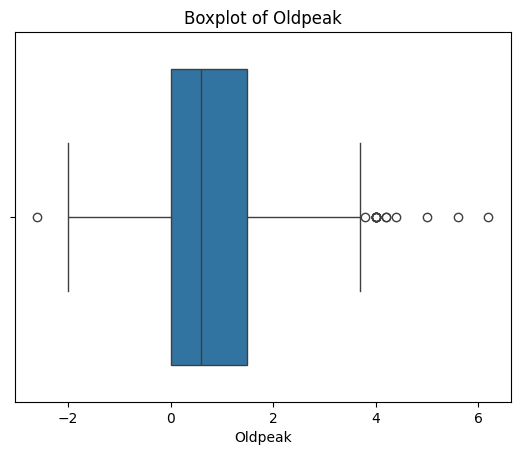

In [ ]:
# Section E – Boxplot

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
# Section F – Interpretation


means = df[cols].mean()
stds = df[cols].std()
skews = df[cols].skew()

print("\n--- Interpretation ---")

print("\nHighest Mean:", means.idxmax(), "=", means.max())
print("Highest Std Dev:", stds.idxmax(), "=", stds.max())
print("Most Skewed:", skews.idxmax(), "=", skews.max())

# Outliers check using IQR
outliers_count = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_count[col] = len(outliers)

max_outlier_col = max(outliers_count, key=outliers_count.get)


--- Interpretation ---

Highest Mean: Cholesterol = 198.7995642701525
Highest Std Dev: Cholesterol = 109.38414455220348
Most Skewed: Oldpeak = 1.0228720218107528


In [ ]:
print("Most Outliers:", max_outlier_col, "=", outliers_count[max_outlier_col])

print("\nConclusion:")
print("The dataset shows variation in health parameters. Some variables are skewed and contain outliers, indicating non-uniform distribution. Proper preprocessing is important before modeling.")

Most Outliers: Cholesterol = 183

Conclusion:
The dataset shows variation in health parameters. Some variables are skewed and contain outliers, indicating non-uniform distribution. Proper preprocessing is important before modeling.
